# Executive summary — refined-products market

**Sample:** 2019-01 → 2026-04 · daily spot · weekly US stocks · monthly EU stocks & flows.

## TL;DR

- **NWE 3-2-1 refining margin** peaked ≈ 105 USD/bbl on 2022-06-06 (post-invasion refinery squeeze). OOS mean 21.6 USD/bbl; ~10% of days sit below zero across every slate.
- **SPR drawdown ≈ 45%** from 2022 peak — dominant US petroleum-policy story of the decade.
- **US refinery utilisation** 89-91% — mid-range on the full EIA 43-year history (44th pct), top third vs last 5 years. Tight-but-not-extreme.
- **Distillate stocks ↔ diesel crack** strongly negatively correlated (≈ −0.5): lower stocks → higher cracks.
- **Med ↔ NWE ULSD** level correlation > 0.99 — one European diesel market in practice.
- **Brent > WTI** on ~95% of days; mean trans-Atlantic spread ≈ +$4/bbl.
- **OPEC ASB cross-check**: our Platts-derived Brent-ULSD NWE crack matches OPEC's Rotterdam-gasoil-vs-Brent series on overlap years (r ≈ 1.0 on 4 annual obs).

Lead chart: [outputs/figures/executive/chart_01_dashboard.png](../outputs/figures/executive/chart_01_dashboard.png)

**Non-specialist readers**: term definitions (3-2-1, ULSD, SPR, backwardation, IS/OOS, …) live at the portfolio root in [../../GLOSSARY.md](../../GLOSSARY.md) — shared across both projects.


In [1]:
import sys
sys.path.insert(0, '..')
from src import CrackSpreadAnalysis, FundamentalsAnalysis, RegionalAnalysis, DataLoader

dl = DataLoader()
cs = CrackSpreadAnalysis(LOADER=dl).load().build(SLATE='3-2-1', REGION='NWE')
fa = FundamentalsAnalysis(LOADER=dl).load()
ra = RegionalAnalysis(LOADER=dl).load()


[CrackSpread 3-2-1/NWE · crude=M1] 1768 days  | mean 23.28 USD/bbl  | max 105.07 on 2022-06-06
[Fundamentals] US stocks 1891w | EU stocks 155m | EU/country 4846 rows | Refinery util monthly 493m / weekly 2272w | US yields 397m | EU intake 4988 rows (36 countries) | EU distillate output 6819 rows | Floating 134m | Cracks 1261d
[Regional] Spot 1842 | FX 6978 | EU imports 1369 | RU exports 1308 | Cracks 1261 | OPEC exports crude/products 2590/2858 rows | Freight clean/dirty 75/126 rows


## State of the market — headline numbers


In [2]:
cs.summary_stats(); print(); fa.summary_stats();


                         3-2-1 / NWE
n                               1768
Mean (USD/bbl)                 23.28
IS mean                        23.66
OOS mean                       21.63
Max              105.07 (2022-06-06)
Min              -30.26 (2020-04-28)
Skewness                        0.59
Ex. kurtosis                    2.44
Days margin < 0          185 (10.5%)

US stocks (latest vs 5y percentile):
                       latest (Mbbl) 5y pct rank  5y mean   5y min..max
Crude_incl_SPR_Mbbl            876.7        72th    874.2    765..1,136
SPR_Crude_Stocks_Mbbl          415.1        66th    438.7      347..638
Gasoline_Stocks_Mbbl           240.9        84th    227.7      205..259
Distillate_Stocks_Mbbl         117.8        50th    118.9      103..146
Total_Products_Mbbl          1,688.7        72th  1,679.2  1,574..1,930

US refinery utilisation: latest = 91.4%, 5y range 70.6%..95.8%
Floating storage: latest = 1,191 kt, 5y mean 814 kt


## Dashboard

Four panels. Refining margin (crack) · crude-stockpile policy (SPR) · refining capacity (utilisation) · product-mix signal (diesel-over-gasoline premium). Anything off-trend here deserves a deeper look in the follow-up notebooks.


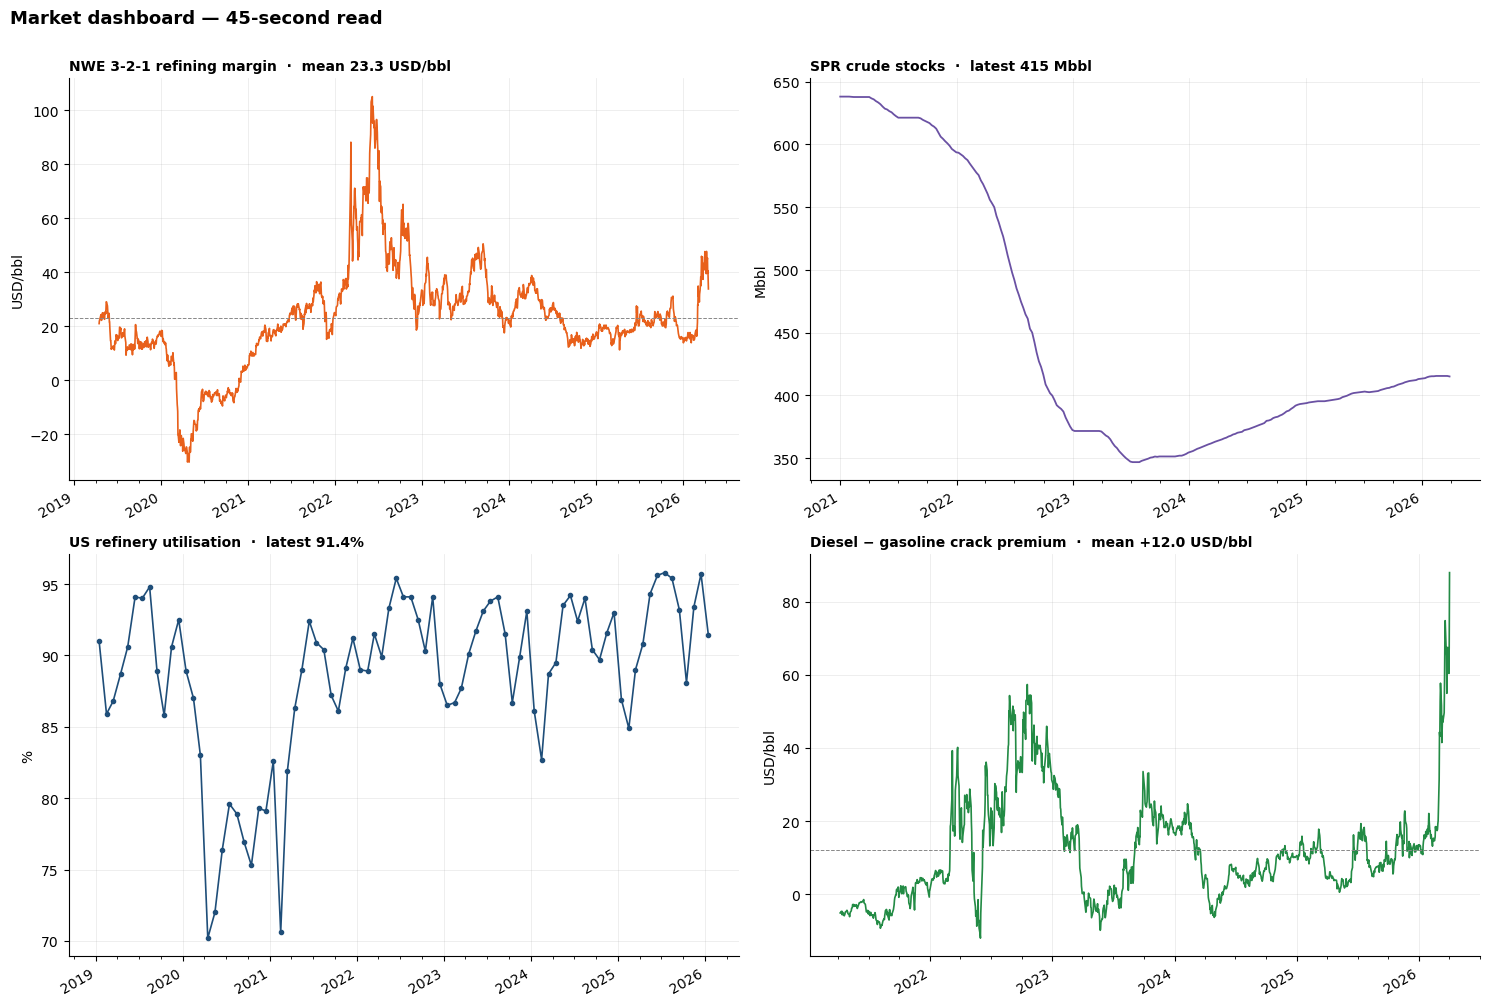

In [3]:
cs.chart_executive_dashboard(FA=fa, RA=ra);


## OPEC MOMR — April 2026 baseline

Numbers taken verbatim from the OPEC Monthly Oil Market Report, April 2026 (pages 5-7 highlights, extracted text at [`../../Datas/Raw_datas/OPEC/MOMR_2026-04_extracted/MOMR_highlights_pages_3-8.txt`](../../Datas/Raw_datas/OPEC/MOMR_2026-04_extracted/MOMR_highlights_pages_3-8.txt)):

| Variable | April 2026 print | Context |
|---|---|---|
| OPEC Reference Basket | $116.36/b *(m-o-m +$48.46)* | Consistent with current dislocation — not a normal print |
| ICE Brent front-month | $99.60/b *(m-o-m +$30.23)* | Our Dated Brent file covers 2026-01-02 → 2026-04-14, peaks in this range |
| NYMEX WTI front-month | $91.00/b *(m-o-m +$26.48)* | Brent-WTI premium stretched to ~$8.60/b in the MOMR numbers |
| DoC crude production | 35.06 mb/d *(m-o-m −7.70 mb/d)* | Large production shortfall — event-driven, not policy |
| World oil demand 2026 | +1.4 mb/d y-o-y | Unchanged from March MOMR |
| Non-DoC supply 2026 | +0.6 mb/d y-o-y | Brazil / US / Canada / Argentina-led |

**Reading these numbers against our chart**: the MOMR average prices are monthly means — they sit below the daily peaks shown in 01/02/03 because they include both the pre-spike and post-spike days of March. Treat MOMR prices as the *period average*, our daily series as the *price path*.

**Why not auto-extract**: the remaining 79 MOMR table CSVs at [`../../Datas/Raw_datas/OPEC/MOMR_2026-04_extracted/`](../../Datas/Raw_datas/OPEC/MOMR_2026-04_extracted/) need hand-mapping per page (multi-row headers, cells that span columns). A one-shot manual pull of the highlights page each quarter is faster than writing a page-specific parser. Re-run quarterly when the next MOMR lands.

## Trading ideas — three setups coming out of this analysis

Each idea: what we think is happening, what trade expresses the view, what triggers entry, what kills it. Sizing is illustrative — real desks run vol-targeted Kelly with entity-level limits.

### 1. Long NWE ULSD crack, short Brent hedge — HIGH conviction

**The view**: Europe structurally can't produce enough diesel to cover what it consumes. The gap is ≈29 Mt/year. That imported barrel sets NWE pricing. Right now three things point the same way — US refineries haven't swung toward distillate despite the tight margin (yield tilt flat), US commercial distillate sits mid-range with no cushion, and the Hormuz crisis has cut AG loadings sharply. When supply is structurally constrained and no flexibility is coming from yield or stocks, the clearing mechanism is price.

**The trade**: long ULSD-only crack (not 3-2-1 composite — the diesel signal is what we're capturing), hedged with Brent short. Use the rolling 60-day β for sizing — currently ≈0.27, meaning roughly one Brent short per 3-4 ULSD cracks long to neutralise the oil-price leg. Rebalance monthly.

**Entry trigger**: ULSD crack crosses above the in-sample 80th percentile *and* US distillate stocks sit in the bottom quintile of the 5y range. Both conditions today.

**What kills it**: signs of EU demand destruction. Watch Eurostat gross inland deliveries — if diesel consumption drops >5% YoY for two consecutive months, cut. Also a credible Hormuz de-escalation headline — the April 7 ceasefire tape unwound jet cracks by $29/bbl in one session.

### 2. Fade the diesel-gasoline premium at extremes — MEDIUM conviction

**The view**: Europe is structurally a net diesel importer and net gasoline exporter — the premium (ULSD crack minus EBOB crack) has been positive on >99% of days, mean around +$10/bbl, typical σ around $8. It's a mean-reverting spread anchored by refinery slate flexibility and the cross-product substitution both sides of the Atlantic. Extreme prints get faded, not chased.

**The trade**: when the premium goes beyond +$18/bbl, short it (short ULSD crack + long EBOB crack). When it dips below +$2/bbl, long it. No directional oil exposure — pair trade. Currently mid-range, no signal.

**What kills it**: structural regime change — EV adoption erodes European diesel demand faster than expected, or a major hydrocracker closure permanently shifts the output balance. Both multi-year moves, unlikely inside a trade horizon.

### 3. The USGC → Med ULSD arb, when US util tightens — MEDIUM conviction

**The view**: when US refinery utilisation prints >94%, the system has zero operational slack. A single unplanned outage — hurricane, cyber, labour action — would spike USGC product prices; Atlantic-basin MR freight would follow; the Med ULSD crack widens mechanically on the loss of US export supply. The 2020s record of sustained >94% is thin: a couple of 2006-2007 weeks and late 2023. When it prints there, things happen quickly.

**The trade**: long Med ULSD crack + long Brent-WTI basin spread. Both legs fire from the same catalyst (US tightness spills cross-Atlantic). Size the basin leg smaller — it's a crude play, lower product-specific edge.

**Entry trigger**: EIA weekly utilisation prints >94% *and* distillate stocks in bottom quintile. Cross-check with the 43-year util chart in [02_Fundamentals.ipynb](02_Fundamentals.ipynb) — don't confuse a post-turnaround bounce with real structural tightness.

**What kills it**: a planned-turnaround-ending print that mimics tightness without the underlying scarcity. Hence the cross-check requirement.

---

**All sizing above is illustrative**. A desk runs these through vol-targeted Kelly, margin-efficient vehicle selection (swaps vs futures), and firm-level risk limits. The value of these ideas isn't in the sizing — it's in the *triggers*, which are observable, falsifiable, and unambiguous.


## Read next

1. **Margins — slate decomposition, regime, regional, rolling hedge, HMM forecast** → [01_Market_Overview.ipynb](01_Market_Overview.ipynb)
2. **Fundamentals — stocks, refinery util (5y + 43y), yields, EU intake, EU consumption** → [02_Fundamentals.ipynb](02_Fundamentals.ipynb)
3. **Regional dynamics — Brent-WTI, Russia, EU imports, OPEC global trade + freight** → [03_Regional_Analysis.ipynb](03_Regional_Analysis.ipynb)
4. **Forward-curve regimes for the same commodities** → [../../Forward_Curves_Analysis/](../../Forward_Curves_Analysis/)
